We will ensure that our identified best models perform better than baseline modelson test data as assessed by EMD loss. Once confirmed, we will re-train a single model using the "best paramaters" on the training + validation data and assess it's performance on the test data. This is simply for the sake of simplicity, to avoid having 5 models that we are assessing.

We generate 4 baseline assessments:
1. Random model: trained on permuted TF labels
2. Perfectly random: simply the EMD loss between the actual test data and permuted test data; this would be the loss of the random model if it had perfect predictions
2. Linear regression
3. FFN: trained using the same hyperparameters as the actual models where applicable

The linear regression and FFN take as input all 3 inputs of scLEMBAS concatenated in one matrix: the stimulation values, one-hot encoding of the cell type, and the expression matrix. For the linear regression, the features of the expression matrix are scaled between 0 and 1 using sklearn's MinMaxScaler.

In [1]:
import os
import scanpy as sc
from tqdm import trange
import itertools

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from geomloss import SamplesLoss

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../.')
from Kang_utils import get_best_hyperparams



[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.model.scl import SignalingModel
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.model_components import FCLayers
from scLEMBAS.model.lr_schedulers import WarmupCosineAnnealingWarmRestarts
from scLEMBAS.preprocess import cohen_d

In [3]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

author = 'Kang'
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')

In [4]:
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

# ensures correct order of test data
# note, this already saved in order, matching the mod.y_out columns
tf_adata = tf_adata[:, sorted(tf_adata.var_names)] 

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

Load best models: 

In [6]:
res = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_k_fold_validation_results.csv'), index_col = 0)
best_emd_mean, best_hyperparams, best_emd = get_best_hyperparams(res)

trainers_best = {k: io.read_pickled_object(os.path.join(models_path, 'Kang_best_trainer_' + str(k) + '.pickle')) for k in range(best_emd.shape[0])}


In [7]:
# sanity check
for k, trainer_k in trainers_best.items():
    trainer_params = [trainer_k.hyper_params['max_epochs'], trainer_k.hyper_params['maximum_learning_rate'], 
             trainer_k.hyper_params['train_batch_size'], trainer_k.hyper_params['vae_scaling_KL']]
    recorded_params = [best_hyperparams['max_epochs'], best_hyperparams['max_lr'], best_hyperparams['train_batch_size'], 
best_emd[best_emd.k == k]['KL_regularization'].tolist()[0]]
    if trainer_params != recorded_params:
        raise ValueError('The stored models do not match the best hyper params')

        


On each fold, let's train a random model with the same parameters and compare the predictions on the test data with the actual model. We also calculate the loss of the random output vs the actual output, which is equivalent to if the random model had perfect predictions on the random data.

In [10]:
def train_FFN(X_train_FFN, y_train_FFN, trainer_k):
    ffn_train_loader = DataLoader(TensorDataset(X_train_FFN, y_train_ffn), 
                                  batch_size=trainer_k.hyper_params['train_batch_size'], 
                                  shuffle=True)

    n_layers_ffn = 3
    ffn_layers = list(np.round(np.linspace(X_train_FFN.shape[1], y_train_ffn.shape[1], n_layers_ffn + 2)).astype(int))
    mod_ffn = FCLayers(layers = ffn_layers, dtype = mod_actual.dtype, device = device)
    ffn_optimizer = torch.optim.Adam(mod_ffn.parameters(), 
                                             lr=trainer_k.hyper_params['maximum_learning_rate'], 
                                             weight_decay=trainer_k.hyper_params['bn_weights_lambda_l2'])
    reset_state = ffn_optimizer.state.copy()
    lr_scheduler = WarmupCosineAnnealingWarmRestarts(optimizer = ffn_optimizer,
                                                          T_0 = trainer_k.hyper_params['lr_restart_epoch'],
                                                          T_mul = trainer_k.hyper_params['lr_restart_factor'], 
                                                          gamma = trainer_k.hyper_params['lr_decay'],
                                                          eta_min = trainer_k.hyper_params['minimum_learning_rate'],
                                                          max_lr=trainer_k.hyper_params['maximum_learning_rate'],
                                                          warmup_steps = trainer_k.hyper_params['warmup_epochs'],
                                                          last_epoch = -1)
    ffn_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05)#.to(device)

    for e in trange(trainer_k.hyper_params['max_epochs']):
        for X_batch, y_batch in ffn_train_loader:
            mod_ffn.train()
            ffn_optimizer.zero_grad()

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred_ffn = mod_ffn(X_batch)
            ffn_loss = ffn_loss_fn(y_pred_ffn, y_batch)

            ffn_loss.backward()
            ffn_optimizer.step()
        lr_scheduler.step()
        if np.logical_and(e % trainer_k.hyper_params['reset_optimizer_epoch'] == 0, e>0):
            ffn_optimizer.state = reset_state.copy()
    return mod_ffn

In [31]:
rand_emd_k, actual_emd_k, untrained_rand_emd_k, linear_emd_k, ffn_emd_k = [], [], [], [], []
stim_map = {'STIM': 1, 'CTRL': 0}

test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()


k_fold_test = pd.DataFrame(columns = ['actual', 'rand', 'perfectly_rand', 'linear', 'FFN'])

for k, trainer_k in trainers_best.items():
    print(k)
    mod_actual = trainer_k.mod
    
    train_cells = trainer_k.X_train.index.tolist()
    
    # ------------permute the tf labels for random model------------
    y_out = mod_actual.y_out.copy()
    np.random.seed(seed)
    permuted_tfs = np.random.permutation(y_out.columns)
    rand_y_out = y_out[permuted_tfs].copy()
    
    # ------------train the linear model------------
    X_in = mod_actual.X_in.copy()
    cats = mod_actual.signaling_network.covariates.copy()
    expr = mod_actual.expr.copy()

    expr_train = expr.loc[train_cells, :]
    cat_dummies = pd.get_dummies(cats, drop_first=True).astype(int)
    scaler = MinMaxScaler(feature_range=(0, 1))
    expr_train_scaled = scaler.fit_transform(expr_train)
    expr_train_scaled = pd.DataFrame(expr_train_scaled, columns = expr_train.columns, index = expr_train.index)
    X_train_linear = pd.concat([X_in.loc[train_cells, :], cat_dummies.loc[train_cells, :], expr_train_scaled], 
             ignore_index = False, axis = 1)
    mod_linear = LinearRegression()
    mod_linear.fit(X_train_linear, y_out.loc[train_cells, :])
    
    # ------------train the FFN------------
    X_train_FFN = pd.concat([X_in.loc[train_cells, :], cat_dummies.loc[train_cells, :], expr_train.copy()], 
         ignore_index = False, axis = 1)
    X_train_FFN = torch.tensor(X_train_FFN.values, dtype = mod_actual.dtype, device = device)
    y_train_ffn = torch.tensor(y_out.loc[train_cells, :].values, dtype = mod_actual.dtype, device = device)
    mod_ffn = train_FFN(X_train_FFN, y_train_ffn, trainer_k)

    # ------------build and train the random model------------
    mod_rand = SignalingModel(net = sn_ppis,
                              X_in = mod_actual.X_in.copy(),
                              y_out = rand_y_out, 
                              expr = mod_actual.expr.copy(), 
                              covariates = mod_actual.signaling_network.covariates.copy(),
                              categorical_covariate_keys = mod_actual.signaling_network.covariates.columns.tolist(),
                              projection_amplitude_in = mod_actual.input_layer.projection_amplitude, 
                              projection_amplitude_out = mod_actual.projection_amplitude_out,
                              weight_label = weight_label, source_label = source_label, target_label = target_label,
                              bionet_params = mod_actual.signaling_network.bionet_params.copy(), 
                              dtype = torch.float32, device = device, seed = seed,
                              rand_y = True)
    mod_rand.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
    mod_rand.signaling_network.prescale_weights(target_radius = mod_actual.signaling_network.bionet_params['spectral_target']) # spectral radius
    
    hyper_params = trainer_k.hyper_params
    hyper_params['validation_batch_size'] = np.nan
    hyper_params['test_batch_size'] = len(test_cells)
    trainer = TrainSC(mod = mod_rand,
                      prediction_optimizer = torch.optim.Adam,
                      prediction_loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device), #torch.nn.MSELoss(reduction='mean'),
                      discriminator_params = trainer_k.discriminator['params'].copy(),
                      hyper_params = hyper_params.copy(),
                  train_split = {'train': train_cells, 'test': test_cells, 'validation': None},
                  train_seed = seed,
                  track_test = False,
                  track_validation = False)

    mod_rand = trainer.train_model(verbose = False)

    # ---------------------------------evaluation---------------------------------
    # calculate loss on test for each of the actual and random model
    # for each condition: get the test condition predictions from all in-distribution gene expression that was trained
    # take the total loss across conditions
    tot_linear, tot_rand, tot_rand_untrained, tot_actual, tot_ffn = 0, 0, 0, 0, 0
    for cond in tf_adata.obs.loc[test_cells, :].condition.unique():
        stim, ct = cond.split('^')
        
        test_cells_cond = tf_adata.obs[(tf_adata.obs.index.isin(test_cells)) & (tf_adata.obs['condition'] == cond)].index.tolist()
        y_test = mod_actual.df_to_tensor(tf_adata.to_df().loc[test_cells_cond, :])
        
        # in distribution gene expression!
        expr_test = mod_actual.df_to_tensor(mod_actual.expr.loc[train_cells, :])
        
        # set the stimulation condition we want to predict
        X_test_df = pd.DataFrame(data = {'IFNB1': [stim_map[stim]]*len(train_cells)})
        X_test = mod_actual.df_to_tensor(X_test_df)

        # set the cell type we want to predict
        cov_idx_map = dict(zip(mod_actual.signaling_network.covariates['seurat_annotations'], 
                               mod_actual.signaling_network.covariates_idx['seurat_annotations']))
        covariates_idx_test = torch.tensor([cov_idx_map[ct]]*len(train_cells), device = mod_actual.device, dtype = torch.int64).view(-1,1)

        # ------------linear model------------
        cat_dummies_test = cat_dummies.loc[train_cells, :].reset_index(drop = True)
        cat_dummies_test[:] = 0
        cat_dummies_test['_'.join(['seurat_annotations', ct])] = 1
        X_test_linear = pd.concat([X_test_df, cat_dummies_test, expr_train_scaled.reset_index(drop = True)],
                                  axis = 1)
        y_pred_linear = mod_linear.predict(X_test_linear)
        y_pred_linear = torch.tensor(y_pred_linear, dtype = mod_actual.dtype, device = mod_actual.device)
        loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device)
        tot_linear += loss_fn(y_pred_linear, y_test).detach().cpu().item()
        
        # ------------FFN------------
        X_test_FFN = torch.tensor(pd.concat([X_test_df, cat_dummies_test, expr_train.reset_index(drop = True)], axis = 1).values, 
                                  device = device, dtype = mod_actual.dtype)
        y_pred_FFN = mod_ffn(X_test_FFN)
        loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device)
        tot_ffn += loss_fn(y_pred_FFN, y_test).detach().cpu().item()
        
        # ------------random prediction - perfect------------
        y_rand = mod_actual.df_to_tensor(tf_adata.to_df().loc[test_cells_cond, rand_y_out.columns])
        loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device)
        tot_rand_untrained += loss_fn(y_rand, y_test).detach().cpu().item()

        # ------------random model - trained------------
        mod_rand.eval()
        with torch.inference_mode():
            y_predicted_rand, _, _ = mod_rand(X_in = X_test, covariates_idx = covariates_idx_test, expr = expr_test)
        loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device)
        tot_rand += loss_fn(y_predicted_rand, y_test).detach().cpu().item()

        # ------------actual model------------
        mod_actual.eval()
        with torch.inference_mode():
            y_predicted_actual, _, _ = mod_actual(X_in = X_test, covariates_idx = covariates_idx_test, expr = expr_test)
        loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device)
        tot_actual += loss_fn(y_predicted_actual, y_test).detach().cpu().item()

        del expr_test, X_test, covariates_idx_test, y_predicted_rand, y_predicted_actual
        del loss_fn, y_rand, X_test_df, X_test_FFN, y_pred_FFN
        torch.cuda.empty_cache()
        
    rand_emd_k.append(tot_rand)
    actual_emd_k.append(tot_actual)
    untrained_rand_emd_k.append(tot_rand_untrained)
    linear_emd_k.append(tot_linear)
    ffn_emd_k.append(tot_ffn)

    k_fold_test.loc[k_fold_test.shape[0],: ] = [tot_actual, tot_rand, tot_rand_untrained, tot_linear, tot_ffn]
    k_fold_test.to_csv(os.path.join(data_path, 'processed', author + '_k_fold_baselines.csv'))
    
    

Visualize results:

In [32]:
k_fold_test = pd.read_csv(os.path.join(data_path, 'processed', author + '_k_fold_baselines.csv'), index_col = 0)
k_fold_test

,actual,rand,perfectly_rand,linear,FFN
0,253.469093,671.161041,707.797394,297.237179,274.906982
1,224.707508,633.975983,707.797394,299.641914,274.235126
2,243.636520,622.309769,707.797394,295.740646,272.011887
3,252.031197,668.626236,707.797394,293.800499,271.816463
4,254.038757,629.075272,707.797394,297.056404,273.537506


In [9]:
viz_df = pd.melt(k_fold_test, var_name = 'model', value_name='loss')
viz_df = viz_df[viz_df.model != 'perfectly_rand']

/tmp/ipykernel_3574133/3260545328.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')


''

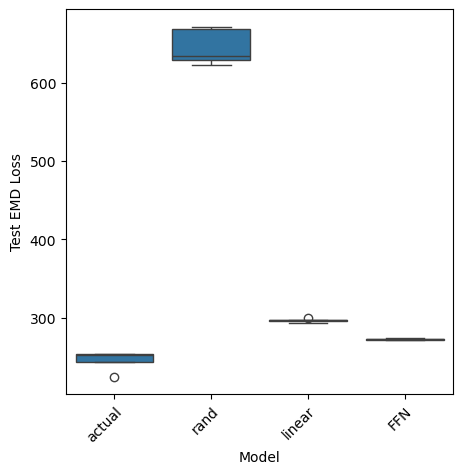

In [10]:
fig, ax = plt.subplots(ncols = 1, figsize = (5,5))

# sns.violinplot(data = viz_df, x = 'model', y = 'loss', ax = ax, palette='muted')
sns.boxplot(data = viz_df, x = 'model', y = 'loss', ax = ax)#, palette='muted')
# sns.scatterplot(data=viz_df, x = 'model', y = 'loss', 
#                 color="gray", ax=ax, s = 10)
# ax.set_yscale('log')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
ax.xaxis.set_tick_params(which='both', bottom=True, top=False, direction='out')
ax.yaxis.set_tick_params(which='major', left=True, right=False, direction='out')
ax.set_ylabel('Test EMD Loss')
ax.set_xlabel('Model')

# # get statistics
comparisons = list(itertools.combinations(viz_df.model.unique(), 2))
pvals = []
effect_size = []
for comp in comparisons:
    comp_0 = viz_df[viz_df.model == comp[0]]['loss']
    comp_1 = viz_df[viz_df.model == comp[1]]['loss']
    _, pval = mannwhitneyu(comp_0, comp_1, alternative = 'two-sided')
    pvals.append(pval)

    effect_size.append(cohen_d(comp_0, comp_1))

_, fdr, _, _ = multipletests(pvals, method='fdr_bh')

# x_pos_dict = dict(zip([tick.get_text() for tick in ax.get_xticklabels()], 
#                       [tick.get_position()[0] for tick in ax.get_xticklabels()]))
# annotation_y_offset = 0.7
# max_y = k_folds_res.samples_pearson.max() + 0.5
# idx_counter = 0
# for idx, ((group1, group2), p_value, effect) in enumerate(zip(comparisons, fdr, effect_size)):

#     significance = "N.S."
#     if p_value <= 1e-4:
#         significance = "****"
#     elif p_value <= 0.001:
#         significance = "***"
#     elif p_value <= 0.01:
#         significance = "**"
#     elif p_value <= 0.1:
#         significance = "*"
#     if significance != "N.S.":
#         x1 = x_pos_dict[group1]
#         x2 = x_pos_dict[group2]
#         x_mid = (x1 + x2) / 2

#         y_pos = max_y + (idx_counter * annotation_y_offset)
#         ax.plot([x1, x2], [y_pos, y_pos], color='black', lw=1.5)
#         annotation_text = "Cohen's D: {:.2f}, ".format(effect) + significance #'Cohen'f"Cohen's d={effect:.2f}"
#         ax.text(x_mid, y_pos + 0.15, annotation_text, ha='center', color='black', fontsize=10)
#         idx_counter += 1

;

In [11]:
stats = pd.DataFrame({'Cohen_d': effect_size, 'MWU_pval': pvals, 'BH_FDR': fdr})
stats = pd.concat([pd.DataFrame(comparisons, columns = ['Model 1', 'Model 2']), 
                  stats], axis = 1)
stats

,Model 1,Model 2,Cohen_d,MWU_pval,BH_FDR
0,actual,rand,-21.555042,0.007937,0.007937
1,actual,linear,-5.745446,0.007937,0.007937
2,actual,FFN,-3.105452,0.007937,0.007937
3,rand,linear,21.243605,0.007937,0.007937
4,rand,FFN,22.770553,0.007937,0.007937
5,linear,FFN,14.178232,0.007937,0.007937
